<a href="https://colab.research.google.com/github/kirti131/Advance-DS-ML/blob/main/Advance_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/kirti131/Advance-DS-ML.git

Cloning into 'Advance-DS-ML'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.


In [ ]:
# This installs R support
!apt-get install -y libssl-dev libcurl4-openssl-dev libxml2-dev
!Rscript -e "IRkernel::installspec(user = FALSE)"


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libcurl4-openssl-dev is already the newest version (7.81.0-1ubuntu1.20).
libssl-dev is already the newest version (3.0.2-0ubuntu1.19).
libxml2-dev is already the newest version (2.9.13+dfsg-1ubuntu0.6).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [ ]:
# Install R magic
!pip install -q rpy2



In [ ]:
%load_ext rpy2.ipython



1. Handle Outliers in R

In [ ]:
%%R
data(iris)

Q1 <- quantile(iris$Sepal.Length, 0.25)
Q3 <- quantile(iris$Sepal.Length, 0.75)
IQR_value <- Q3 - Q1

lower_bound <- Q1 - 1.5 * IQR_value
upper_bound <- Q3 + 1.5 * IQR_value

iris_no_outliers <- iris[iris$Sepal.Length >= lower_bound & iris$Sepal.Length <= upper_bound, ]

cat("Outliers removed based on Sepal.Length:", nrow(iris) - nrow(iris_no_outliers), "\n")



Outliers removed based on Sepal.Length: 0 


In [ ]:
!pip install -q rpy2


In [ ]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


2. Handle Invalid Values in R

In [ ]:
%%R
# Simulate invalid values
iris_with_invalid <- iris
iris_with_invalid$Sepal.Length[c(5, 10)] <- NA  # Add missing (invalid) values

# Handle: Replace NA with median
iris_with_invalid$Sepal.Length[is.na(iris_with_invalid$Sepal.Length)] <- median(iris$Sepal.Length, na.rm = TRUE)

# View result
print("Handled invalid values (NA replaced with median):")
summary(iris_with_invalid$Sepal.Length)


[1] "Handled invalid values (NA replaced with median):"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  4.300   5.100   5.800   5.855   6.400   7.900 


3. Visualize Iris Dataset Using Mosaic Plot


In [ ]:
%%R
install.packages(c("zoo", "colorspace", "lmtest", "vcd"))


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/zoo_1.8-14.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/colorspace_2.1-1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/lmtest_0.9-40.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/vcd_1.4-13.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpiomLrA/downloaded_packages’


In [ ]:
%%R
library(vcd)




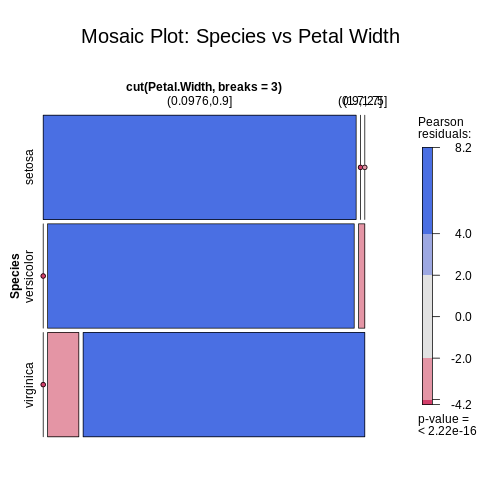

In [ ]:
%%R
mosaic(
  ~ Species + cut(Petal.Width, breaks=3),
  data=iris,
  shade=TRUE,
  legend=TRUE,
  main="Mosaic Plot: Species vs Petal Width"
)


In [ ]:
!pip install -q rpy2

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


5. Linear Regression on Mouse Data


Call:
lm(formula = weight ~ height)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.5059 -1.3910  0.2515  0.9794  2.0382 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -28.90893   11.14159  -2.595   0.0319 *  
height        0.62867    0.07657   8.211 3.62e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.413 on 8 degrees of freedom
Multiple R-squared:  0.8939,	Adjusted R-squared:  0.8807 
F-statistic: 67.42 on 1 and 8 DF,  p-value: 3.619e-05



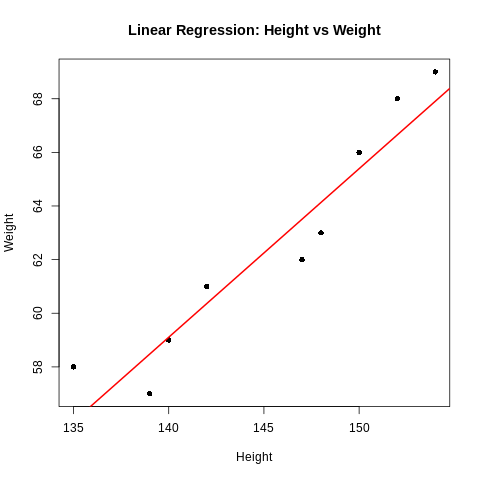

In [ ]:
%%R
# Mice data
height <- c(140,142,150,147,139,152,154,135,148,147)
weight <- c(59, 61, 66, 62, 57, 68, 69, 58, 63, 62)

# Linear regression
model <- lm(weight ~ height)

# Summary
print(summary(model))

# Plot regression line
plot(height, weight,
     main = "Linear Regression: Height vs Weight",
     xlab = "Height", ylab = "Weight", pch = 16)
abline(model, col = "red", lwd = 2)
